In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW

In [2]:
rotor = IEA10MW()

nElements = 37
nSections = 158

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
wrfles_bem = []
# wrfles_wind = []
wrfles_bem.append(dict(np.load('/home1/09909/smata/dir_scratch/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/up_40/case_4/U07_lite.npz')))

In [5]:
file_list = glob.glob("/home1/09909/smata/dir_scratch/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/up_40/case_4/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['diameter']/2 + 378

In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

/tmp/ipykernel_85144/1816889854.py:108: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)


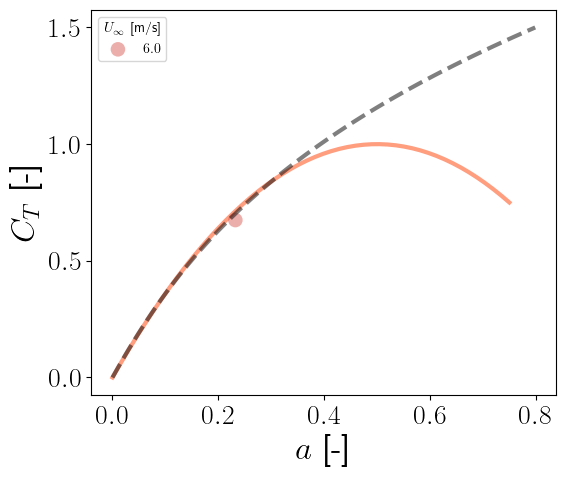

In [8]:
xs = [0,1,1,1,2,3,3,3,3,3,4,5,5,5,6]
ys = [2,1,2,3,2,0,1,2,3,4,2,1,2,3,2]

leg_strs = ['$6.0$','$7.0$','$8.0$', '$9.0$', '$10.0$']

ind_rotor = np.zeros_like(xs, dtype=float)
ct_rotor  = np.zeros_like(xs, dtype=float)

ind_loc = np.zeros((nElements, nSections, len(xs)))
ct_loc  = np.zeros((nElements, nSections, len(xs)))

colors = sns.color_palette("hls", 5)

fig, ax = plt.subplots(figsize=(6, 5))

casenames = ['case_4']

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Get radial points
    # a = ((wrfles_bem[count]['rOverR'] * rotor.R) - rotor.hub_radius)/rotor.R
    # r = (rotor.hub_radius + a * (rotor.R - rotor.hub_radius)) / rotor.R

    r = wrfles_bem[count]['rOverR'] * rotor.R

    # Compute induction
    # ind = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / u_inf.T
    ind = 1 - np.mean(wrfles_bem[count]['u'],axis=0) / u_inf.T


    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    # Solidity
    # sigma = rotor.solidity_func(r)

    chord = [
4.6263,
4.8221,
5.0180,
5.2139,
5.4098,
5.6056,
5.8015,
5.9478,
5.9695,
5.8650,
5.6554,
5.4459,
5.2363,
5.0268,
4.8173,
4.6077,
4.3982,
4.1886,
3.9759,
3.7489,
3.5219,
3.2949,
3.0984,
2.9071,
2.7159,
2.5216,
2.3107,
2.0998,
1.8889,
1.6780,
1.4671,
1.2562,
1.0453,
0.8344,
0.6234,
0.4125,
0.2016,
    ]

    chord =  (np.ones_like(Cd.T) * chord).T

    sigma = (3 * chord) / (2 * np.pi * r)

    # Relative velocity
    W = np.mean(wrfles_bem[count]['vrel'], axis=0) / ((u_inf**2 + v_inf**2)**(1/2)).T

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    # ct = sigma * W**2 * Cax * wrfles_bem[count]['shapiroM'][0]**2
    ct = sigma * W**2 * Cax

    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct, np.linspace(0, 2*np.pi, nSections), axis=-1)
    ind_annular = 1/(2 * np.pi) * np.trapezoid(ind, np.linspace(0, 2*np.pi, nSections), axis=-1)

    ct_rotor[count]  = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    ind_rotor[count] = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

plt.legend(title='$U_{\infty}$ [m/s]')

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()

In [14]:
ind_rotor

array([0.25792918, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [22]:
ct_rotor

array([0.75556637, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [9]:
[ind_rotor[0], ct_rotor[0]]

[np.float64(0.23219937331067647), np.float64(0.6745140841333495)]

In [10]:
base  = [np.float64(0.23185408150849574), np.float64(0.6730635591260987)]
up_10 = [np.float64(0.2320335056392317), np.float64(0.6739349029426307)]
up_20 = [np.float64(0.2322286953227797), np.float64(0.6748128899800753)]
up_30 = [np.float64(0.23272923504547383), np.float64(0.6762263603051568)]
up_40 = [np.float64(0.23219937331067647), np.float64(0.6745140841333495)]


(0.66, 0.7)

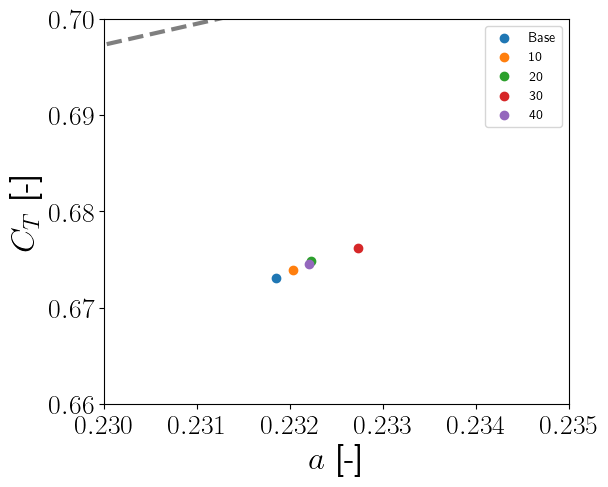

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(base[0],base[1],  label = 'Base')
ax.scatter(up_10[0],up_10[1],label = '10%')
ax.scatter(up_20[0],up_20[1],label = '20%')
ax.scatter(up_30[0],up_30[1],label = '30%')
ax.scatter(up_40[0],up_40[1],label = '40%')

ax.legend()

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

ax.set_xlim([0.23,0.235])
ax.set_ylim([0.66,0.70])